<a href="https://colab.research.google.com/github/aminmoosavi/__PyTorch__/blob/main/PyTorch_00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch. Day 0
In this notebook, we will learn to
* **Create simple torch tensors** and
* **Do operations on tensors**

We will further learn how to create a simple linear regression model using PyTorch, through which We will learn the basics of
* **Building a model**
* **Training via back propagation**
* **Testing**

## <font color="red">**importing**:</font>
* **PyTorch**  
* **NumPy**  
* **matplotlib**


In [4]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

* **Do I have GPU access on google colab?**
There is usually a free GPU available on google colab. If you want more, you should pay for it.

In [5]:
!nvidia-smi

Tue Jun 30 20:58:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

* **What PyTorch version?**

In [6]:
print(torch.__version__)

2.11.0+cu128


# Basics of tensors and their operations:
## <font color="red">**Torching the tensos**:</font>
* Use ```
tensor = torch.tensor() ``` to **create simple tensors**. They can come in any dimensions and shapes.

* Use ``` tensor.ndim ``` to **find the dimensions of your tensor**

* Use ``` tensor.shape ``` to **find the shape of your tensor**

* Use ``` tensor.dtype ``` to **find the data type of your tensor**

* Use ``` tensor.device ``` to **find the device that has access to the tensor**

In [7]:
# Tensor examples

# Scalar
Scalar_tensor = torch.tensor(10)
print('Scalar dimensions =',Scalar_tensor.ndim)
print('Scalar shape =',Scalar_tensor.shape)
print('Scalar data type =',Scalar_tensor.dtype)
print('--------------------------------------------')


# Vector
Vector_tensor=torch.tensor(
[1,2,3]
                            )
print('Vector dimensions =',Vector_tensor.ndim)
print('Vector shape =',Vector_tensor.shape)
print('--------------------------------------------')


# 2D
Two_tensor=torch.tensor(
    [[1,2,3],
      [3,4,5],
      [4,5,6],
      [-1,-2,-3],
      [-3,-4,-5],
      [-4,-5,-6]]
)
print('2D tensor dimensions =',Two_tensor.ndim)
print('2D tensor shape =',Two_tensor.shape)
print('--------------------------------------------')


# 3D
Three_tensor=torch.tensor(
    [[[1,2,3],
      [3,4,5],
      [4,5,6]],
       [[-1,-2,-3],
      [-3,-4,-5],
      [-4,-5,-6]]]
)
print('3D tensor dimensions =',Three_tensor.ndim)
print('3D tensor shape =',Three_tensor.shape)

Scalar dimensions = 0
Scalar shape = torch.Size([])
Scalar data type = torch.int64
--------------------------------------------
Vector dimensions = 1
Vector shape = torch.Size([3])
--------------------------------------------
2D tensor dimensions = 2
2D tensor shape = torch.Size([6, 3])
--------------------------------------------
3D tensor dimensions = 3
3D tensor shape = torch.Size([2, 3, 3])


* **Accessing tensor elements** The following is a three dimensional tensor. Note the number of opened brackets ```[[[ ``` each in a different color.

In [8]:
Tensor=torch.tensor(
    [[[1,2,3],
      [3,4,5],
      [4,5,6]],
       [[-1,-2,-3],
      [-3,-4,-5],
      [-4,-5,-6]]]
)


print(Tensor[0])
print('--------------------------------------------')
print(Tensor[0,1])
print('--------------------------------------------')
print(Tensor[0,1,0])

tensor([[1, 2, 3],
        [3, 4, 5],
        [4, 5, 6]])
--------------------------------------------
tensor([3, 4, 5])
--------------------------------------------
tensor(3)


* **Generating Random Tensors of different shapes and sizes. Many different distributions are available to sample.**

In [9]:
# Standard Normal distribution
random_Tens = torch.randn(4,6)
# Or
random_Tensor = torch.normal(0, 1, size=(4,6))
print('Tensor dimensions:',random_Tensor.ndim)
print('Tensor data type =',random_Tensor.dtype)
print('--------------------------------------------')

# Uniform distribution in the range [0,1]
random_Im=torch.rand(size=(256,256,3))
print('Image dimensions:',random_Im.ndim)
print('Image shape:',random_Im.shape)

Tensor dimensions: 2
Tensor data type = torch.float32
--------------------------------------------
Image dimensions: 3
Image shape: torch.Size([256, 256, 3])


* **Zeros and ones.**
Use ``` torch.zeros(size=) ```

In [10]:
zero_Tens=torch.zeros(size=(9,12))
print(zero_Tens)
one_Tens=torch.ones(4,4)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])


* **Creating a range of numbers.**
Use
``` torch.arange(start = ,end = ,step = ) ```


In [11]:
d_range=torch.arange(start=0,end=14,step=0.1)
zeros_like_d_range = torch.ones_like(input=d_range)
print(zeros_like_d_range.shape)

torch.Size([140])


### Important Tensor attributes:
* **dtype : Data type of the tensor**
* **Device : The device (cpu or gpu) that has access to and can operate on the tensor**
* **requres_grad : Do you want to keep track of the gradient of the tensor in a model?**  

In [12]:
# tensor data types, devices, requires_grad?
Tensor=torch.tensor( [1,2,3],
                          dtype = torch.float32,
                          device = None,
                          requires_grad = False )
print( f"Data type = {Tensor.dtype}" )
print( "Device = ", Tensor.device )
print( "Requires_grad = ",Tensor.requires_grad)

Data type = torch.float32
Device =  cpu
Requires_grad =  False


##<font color="red">**Tensor ops**:</font>
* **One important thing to be careful about is matrix multiplication (be careful with dimensions and shapes of the tensors)**
$C_{(m \times n)}=A_{(m \times q)} B_{(q \times n)}$
* **Tensor operations are some times sensitive to dtype**
* **Tensor operations involving more than one tensor must be done one the same device**

In [13]:
# matrix multiplication
T = torch.rand( 2 , 6 )
print( "Shape of T = ", T.shape )
print( "Shape of T.T = ", T.T.shape )
q = torch.mm( T.T , T )
print( "Shape of q = T.T @ T ", q.shape )

Shape of T =  torch.Size([2, 6])
Shape of T.T =  torch.Size([6, 2])
Shape of q = T.T @ T  torch.Size([6, 6])


* **Mean, max, min, sum**

In [14]:
print('mean = ',Tensor.mean())
print('max = ',Tensor.max())
print('sum = ',Tensor.sum())
print('min = ',Tensor.min())
print('minpos = ', Tensor.argmin())
print('maxpos = ', Tensor.argmax())

mean =  tensor(2.)
max =  tensor(3.)
sum =  tensor(6.)
min =  tensor(1.)
minpos =  tensor(0)
maxpos =  tensor(2)


* **Reshape the tensor by reshape or view**
* **Clone the tensors if you want independent copies**

In [15]:
T = torch.rand( 2 , 6 )
T_re = T.reshape(1,12).clone()
T_vi = T.view(1,12).clone()
T_vi[0,8]=5000

print(T.max())
print(T_re.max())
print(T_vi.max())

tensor(0.9126)
tensor(0.9126)
tensor(5000.)


* **Squeeze and unsqueeze**

In [16]:
u=torch.squeeze(T[:,3])
v=torch.squeeze(T[1,:])
print('Shape of u=',u.shape)
print('Shape of v=',v.shape)
print('---------------------------------')
U=torch.unsqueeze(u,1)
V=torch.unsqueeze(u,0)
print('Shape of U=',U.shape)
print('Shape of V=',V.shape)


Shape of u= torch.Size([2])
Shape of v= torch.Size([6])
---------------------------------
Shape of U= torch.Size([2, 1])
Shape of V= torch.Size([1, 2])


* **Stack the tensors**

In [17]:
X=torch.stack([T,T],1)
T[0,0]=10000
print("X shape = ",X.shape)

X shape =  torch.Size([2, 2, 6])


* **Permutate the tensors.**

In [18]:
# Y is permutated version of X. If either X or Y change it is reflected in the other one
Y=X.permute(2,1,0)
print("Y shape = ",Y.shape)
print(X.max())
print(Y.max())

Y shape =  torch.Size([6, 2, 2])
tensor(0.9126)
tensor(0.9126)


* **Random number reproducibility**

In [19]:
torch.manual_seed(37)
torch.rand(3,3)

tensor([[0.7911, 0.6419, 0.8091],
        [0.1659, 0.3555, 0.6189],
        [0.9651, 0.2761, 0.7416]])

* **check for gpu access on PyTorch**

In [37]:
print(torch.cuda.is_available())

True


* **Move a tensor to a particular device**

In [38]:
device="cuda" if torch.cuda.is_available() else "cpu"
T_on_gpu = T.to(device)

* **Matrix operations must be faster on a gpu**

In [39]:
%%time
torch.mm(T_on_gpu,T_on_gpu.T)

CPU times: user 756 µs, sys: 95 µs, total: 851 µs
Wall time: 549 µs


tensor([[1.0000e+08, 2.8786e+03],
        [2.8786e+03, 2.0617e+00]], device='cuda:0')

In [40]:
%%time
torch.mm(T,T.T)

CPU times: user 15 µs, sys: 755 µs, total: 770 µs
Wall time: 1.37 ms


tensor([[1.0000e+08, 2.8786e+03],
        [2.8786e+03, 2.0617e+00]])

# Model_0
This is the first torch model we build, train, and test.

##<font color="red">**Modeling**:</font>


* **Data preparing and loading**
* **Building model**
* **Training via back probagation minimizing a loss function**
* **Testing**


In [24]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.11.0+cu128'

* **Data preparing and loading** We start simple. This is a linear model with some additive Gaussian noise

In [25]:
# True model parameters
weight = 1.5
bias = -1

# Input data
X = torch.arange(start=0.0,end=1.0,step=0.01).unsqueeze(dim=1)
torch.manual_seed(13)
noise = 0.1*torch.randn_like(X) # Gaussian white noise
# Observed output data
Y = weight * X + bias + noise # linear plus some

* **Splitting data into training and test**

In [26]:
# Generating a shuffled data indices
shuffled_indices = torch.randperm(X.size()[0])

# Use 75 percent of the data points for training and 25 percent for testing
# We could have a validation set (Will get back to this in the future)
train_split = int(0.75 * len(X))

# Splitting the data
X_train , Y_trian = X[shuffled_indices[:train_split]] , Y[shuffled_indices[:train_split]]
X_test , Y_test = X[shuffled_indices[train_split:]] , Y[shuffled_indices[train_split:]]


* **Always visualize the data**

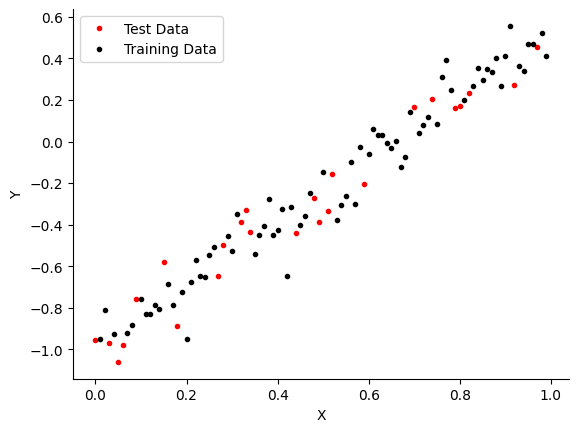

In [27]:
fig, ax = plt.subplots()
ax.plot(X_test,Y_test,'r.',label='Test Data')
ax.plot(X_train,Y_trian,'k.',label='Training Data')
ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

* **First PyTorch model** We build a class for the model that inherits nn.Module

In [28]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32 ))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32 ))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weight * x + self.bias


In [29]:
# Setting the random seed to start from the same initial conditions every time
torch.manual_seed(64)
# instantiating the model
model_0 = LinearRegressionModel()

# Looking at the initail state of the model
model_0.state_dict()

OrderedDict([('weight', tensor([-0.8159])), ('bias', tensor([0.6431]))])

* **Making predictions in```torch.inference_mode()```**

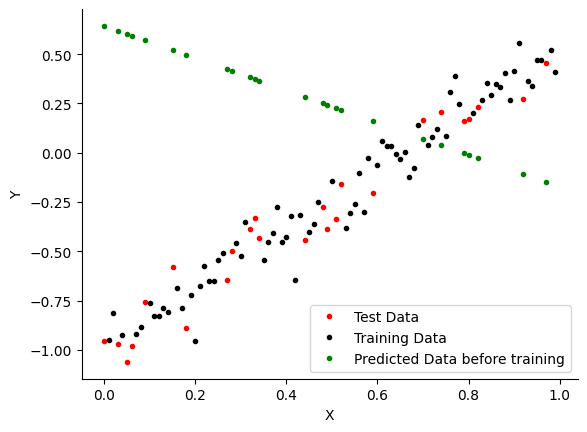

In [30]:
with torch.inference_mode():
  y_preds = model_0(X_test)
fig, ax = plt.subplots()

ax.plot(X_test,Y_test,'r.',label='Test Data')
ax.plot(X_train,Y_trian,'k.',label='Training Data')
ax.plot(X_test,y_preds,'g.',label='Predicted Data before training')
ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

##<font color="red">**Training**:</font>
* Need a **loss function**
* Need an **optimizer**
* Need a **training loop**
* Need **testing**

* **Setting up the loss function** There are many loss functions available in PyTorch. Here, we choose the Mean Squared Error loss function for the linear regression.

In [31]:
loss_fn = nn.MSELoss()

* **Setting the optimizer (stochastic gradient descent (SGD) )**
There are many optimizers available.


In [32]:
# The SGD optimizer. lr is the learning rate
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.02)

* **Training loop**

In [33]:
epochs = 2500
losses=torch.zeros(epochs)
losses_test=torch.zeros(epochs)
for epoch in range(epochs):
  model_0.train() # train mode in PyTorch activated

  #1. forward pass
  Y_pred = model_0(X_train)

  #2. Calculate the loss
  loss=loss_fn(Y_pred,Y_trian)
  # print(f"loss = {loss}")
  losses[epoch]=loss

  #3. Optimizer zero grad resets the gradient to zero
  optimizer.zero_grad()

  #4. Perform backpropagation
  loss.backward()

  #5. Step the optimizer (gradient descent)
  optimizer.step()

  model_0.eval() # Set the module in evaluation mode
  with torch.inference_mode():
    #1 forward pass the test data
    Y_pred_test = model_0(X_test)

    #2 calculate test loss
    loss_test=loss_fn(Y_pred_test,Y_test)
    losses_test[epoch] = loss_test

* **Visualizing the loss**

Estimated weight= 1.5098216533660889 ------- True weight =  1.5
Estimated bias= -0.9863976836204529 ------- True bias =  -1


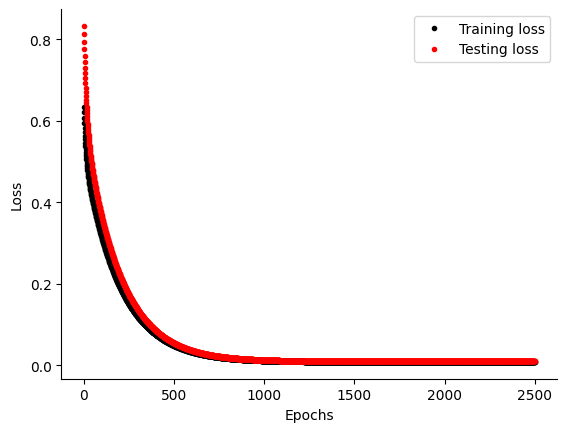

In [34]:

print('Estimated weight=',model_0.weight.item() ,  '------- True weight = ', weight)
print('Estimated bias=',model_0.bias.item() ,  '------- True bias = ' , bias)

# casting the loss tensors into NumPy arrays
lossvals=losses.detach().numpy()
lossvals_test=losses_test.detach().numpy()

# plotting the loss functions
fig, ax = plt.subplots()
plt.plot(lossvals,'.',c='k',label = 'Training loss')
ax.plot(lossvals_test,'.',c='r',label = 'Testing loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

* **Visualizing the data after training**

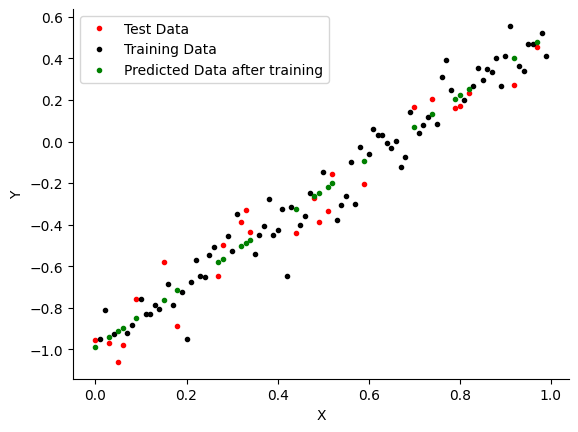

In [35]:
with torch.inference_mode():
  y_preds = model_0(X_test)
fig, ax = plt.subplots()

ax.plot(X_test,Y_test,'r.',label='Test Data')
ax.plot(X_train,Y_trian,'k.',label='Training Data')
ax.plot(X_test,y_preds,'g.',label='Predicted Data after training')
ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()